<a href="https://colab.research.google.com/github/syedak1/neuralnetworks/blob/main/buildingmicrograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [184]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

defining value class here

In [185]:
# making the value class

class Value:
# second param makes it so operators store the 'values' the operations happened on
# grad of a value is the derivative of the output, with respect to the  value. basically how much affecting that value affects the output
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
      return f"Value(data={self.data})"

  def __add__(self,other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __radd__(self,other):
    return self + other

  def __mul__(self,other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      # it's being multiplied by out.grad because of chain rule.
      # the grad is how it affects the WHOLE function.
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out

  def __rmul__(self,other):
    return self * other

  def __truediv__(self,other):
    return self * other**-1

  def __neg__(self):
    return self * -1

  def __sub__(self,other):
    return self + (-other)

  def __pow__(self,other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
      self.grad += (other * self.data**(other-1)) * out.grad
    out._backward = _backward
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t ** 2) * out.grad
    out._backward = _backward
    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

# the _backward function works by starting at a node, and looking at its saved
# backwards function. the function will contain frames of other values it needs
# to perform the operation.

# we chain the grad of functions by doing the local deriv and multiplying it by out.grad

In [186]:
a = Value(2.0)
a + 1

Value(data=3.0)

In [187]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

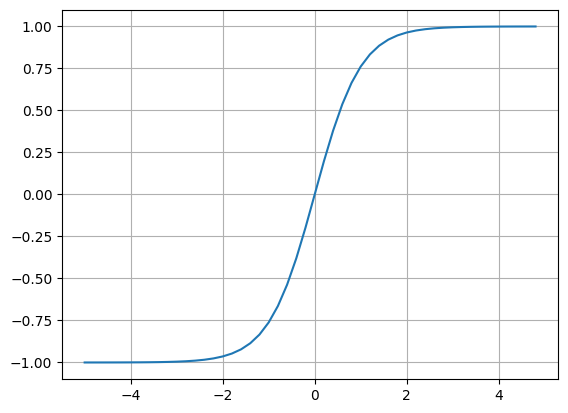

In [188]:
# neuron squashing

plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [189]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
# computation for raw activation without squish, (the z(x) from 3b1b)
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# n is now the raw activation without the squisher
o = n.tanh(); o.label = 'o'

In [190]:
o.backward()

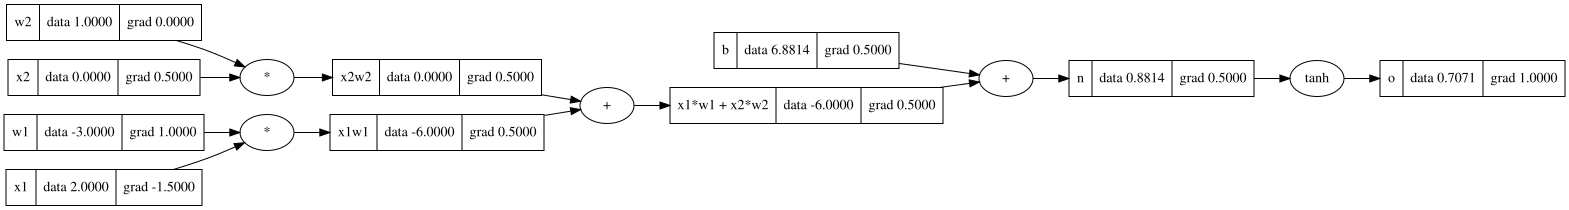

In [191]:
draw_dot(o)

In [192]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
# computation for raw activation without squish, (the z(x) from 3b1b)
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# n is now the raw activation without the squisher
# --- changing how we're defining o
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ---

o.label = 'o'

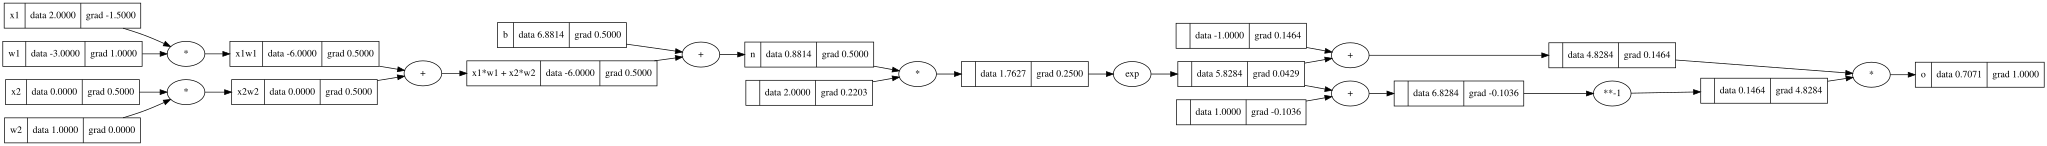

In [193]:
o.backward()
draw_dot(o)

In [194]:
# trying out in pytorch

import torch

In [195]:

# creating tensor with single element and casting to double
# python default uses double precision

# leaf nodes by default do not require gradients, effeciency reasons
# it's because inputs don't require weight updates
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)
print(o.data.item())

o.backward()

print('---')
print('x2', x2.grad.item())
print('x1', x1.grad.item())
print('w2', w2.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
x1 -1.5000003851533106
w2 0.0
w1 1.0000002567688737


building out actual neural net

In [196]:
class Neuron:

  def __init__(self, nin):

    # weight is a random val from 0 to 1
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    # bias is a random val from 0 to 1
    self.b = Value(random.uniform(-1,1))

  def __call__(self,x):

    # when called, multiply all the weights by all corresponding x values
    # then we add them all by b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def __repr__(self):
    return f"Neuron(nin={len(self.w)}, bias={self.b.data:.4f})"


class Layer:

  def __init__(self, nin, nout):
     self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self,x):
     outs = [n(x) for n in self.neurons]
     return outs[0] if len(outs) == 1 else outs

  def __repr__(self):
    return f"Layer(neurons={len(self.neurons)})"

# a list is the input for nout, as the sizes for all the layers in the MLP
class MLP:

  def __init__(self, nin, nouts):
    # adds the lists together
     sz = [nin] + nouts
     self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
      for layer in self.layers:
        x = layer(x)
      return x

# without a loss calculation, backprop, and optimization, the output is just noise
# it would just be multiplying the x values by random

# first param is the input layer, next param is the size of the MLP layers afterwards.
# so this would draw as 3 starting inputs, connected to layer of 4, conected to layer of 4
# the output is then 1 neuron
# x is the values for each of the inputs, so the size has the to match nin for MLP
n = MLP(3, [4, 4, 1])
x = [2.0, 3.0, -1.0]
n(x)


Value(data=0.4693241258149118)

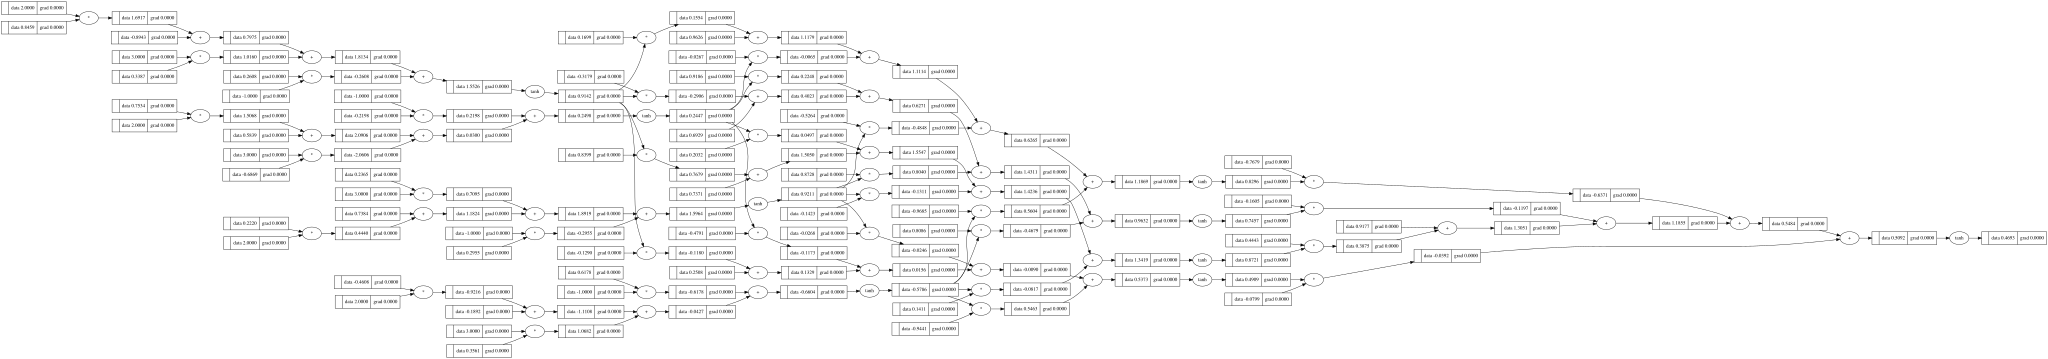

In [197]:
draw_dot(n(x))

In [198]:
xs = [
    [2.0, 3.0, -1.0],
    [-1.0, 3.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
# we want simple binary classifier
# we are kind of just arbitrarily mapping the xs values to the outputs we want it to find
# but it works bc we train it to predict what numbers we have based on punishing and rewarding it
ys = [1.0, -1.0, -1.0, 1.0]
ypred = [n(x) for x in xs]
ypred

[Value(data=0.4693241258149118),
 Value(data=0.8201403001948188),
 Value(data=0.7850580587382174),
 Value(data=0.33475681123530204)]

In [199]:
# mean squared error loss
# zip up the wanted with predictions, and do the prediction - actual and square them for each
# we're just squaring it to discard the sign
# only when prediction is exactly the target do we get zero
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=7.223508369099468)

In [200]:
loss.backward()

In [201]:
print(n.layers[0].neurons[0].w[0])
print(n.layers[0].neurons[0].w[0].grad)

Value(data=0.8458592373974367)
-0.46184732702787124


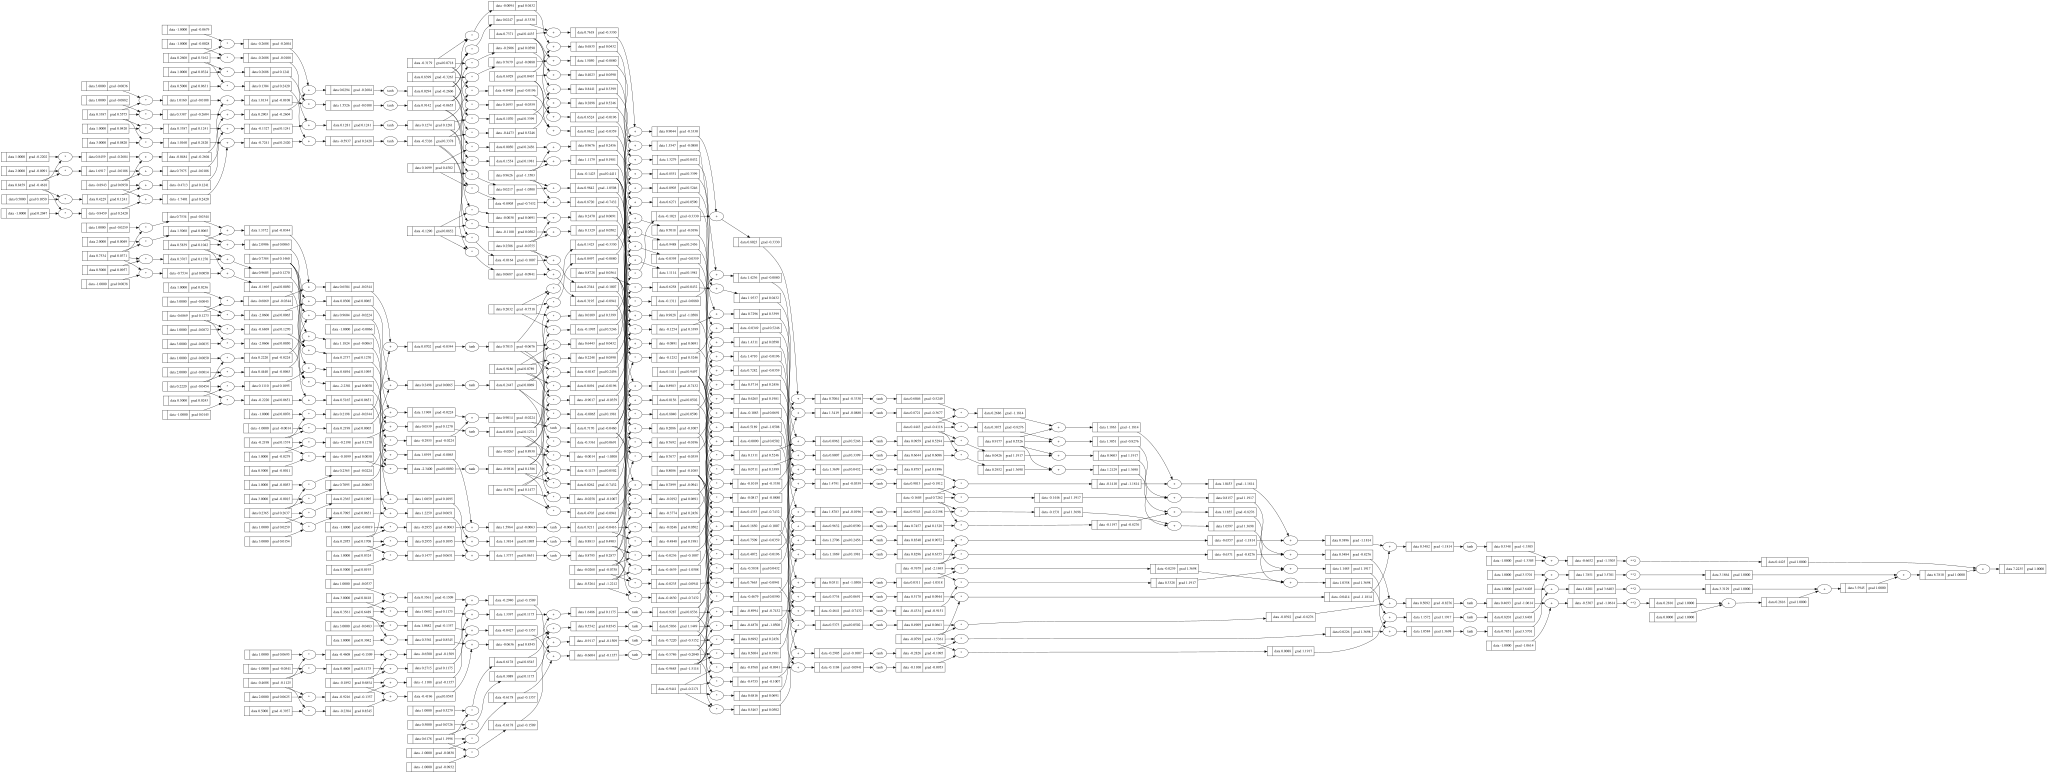

In [202]:
draw_dot(loss)